<a href="https://colab.research.google.com/github/nadiia2302/python_for_ds_tasks/blob/main/HW_15_4_A_B_Test_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Аналіз A/B-тестів

Ви - аналітик даних в ІТ-компанії і до вас надійшла задача проаналізувати дані A/B тесту в популярній [грі Cookie Cats](https://www.facebook.com/cookiecatsgame). Це - гра-головоломка в стилі «з’єднай три», де гравець повинен з’єднати плитки одного кольору, щоб очистити дошку та виграти рівень. На дошці також зображені співаючі котики :)

Під час проходження гри гравці стикаються з воротами, які змушують їх чекати деякий час, перш ніж вони зможуть прогресувати або зробити покупку в додатку.

У цьому блоці завдань ми проаналізуємо результати A/B тесту, коли перші ворота в Cookie Cats було переміщено з рівня 30 на рівень 40. Зокрема, ми хочемо зрозуміти, як це вплинуло на утримання (retention) гравців. Тобто хочемо зрозуміти, чи переміщення воріт на 10 рівнів пізніше якимось чином вплинуло на те, що користувачі перестають грати в гру раніше чи пізніше з точки зору кількості їх днів з моменту встановлення гри.

Будемо працювати з даними з файлу `cookie_cats.csv`. Колонки в даних наступні:

- `userid` - унікальний номер, який ідентифікує кожного гравця.
- `version` - чи потрапив гравець в контрольну групу (gate_30 - ворота на 30 рівні) чи тестову групу (gate_40 - ворота на 40 рівні).
- `sum_gamerounds` - кількість ігрових раундів, зіграних гравцем протягом першого тижня після встановлення
- `retention_1` - чи через 1 день після встановлення гравець повернувся і почав грати?
- `retention_7` - чи через 7 днів після встановлення гравець повернувся і почав грати?

Коли гравець встановлював гру, його випадковим чином призначали до групи gate_30 або gate_40.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Для початку, уявімо, що ми тільки плануємо проведення зазначеного А/B-тесту і хочемо зрозуміти, дані про скількох користувачів нам треба зібрати, аби досягнути відчутного ефекту. Відчутним ефектом ми вважатимемо збільшення утримання на 1% після внесення зміни. Обчисліть, скільки користувачів сумарно нам треба аби досягнути такого ефекту, якщо продакт менеджер нам повідомив, що базове утримання є 19%.

**Формулювання цільового формату даних**

Для A/B test: "користувач-група-результат"

Розмір вибірки:
1) статистична потужність (зазвичай 0.8)
2) рівень значущості (alpha = 0.5)
3) очікувана величина ефекту: базова конверсія - 19%, очікуємо зміну на 20%. Тобто величина ефекту - 1 відсотковий пункт

In [31]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mlp
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

%matplotlib inline

In [32]:
effect_size = sms.proportion_effectsize(0.19, 0.2)


In [33]:
effect_size

np.float64(-0.025241594409087353)

In [34]:
calc = sms.NormalIndPower()

In [35]:
required_n = calc.solve_power(
    effect_size,
    power = 0.8,
    alpha = 0.05,
    ratio = 1
)

required_n = ceil(required_n)

print(required_n)

24638


2. Зчитайте дані АВ тесту у змінну `df` та виведіть середнє значення показника показник `retention_7` (утримання на 7 день) по версіям гри. Сформулюйте гіпотезу: яка версія дає краще утримання через 7 днів після встановлення гри?

H0: p = p0 рівень утримання  через 7 днів у групах gate_30 і gate_40 однаковий

Ha: p != p0 рівень утримання через 7 днів у групах gate_30 і gate_40 відрізняється

Рівень значущості = 95%

alpha = 5%

Очікувана величина ефекту: базова конверсія - 19%, очікуємо зміну на 20%. Тобто величина ефекту - 1 відсотковий пункт

In [36]:
df = pd.read_csv('/content/drive/MyDrive/statistical_hypothesis/cookie_cats.csv')

In [37]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [38]:
print('Кількість рядків:', len(df))
print('Кількість унікальних userid:', df['userid'].nunique())
print('Є дублікати?', len(df) != df['userid'].nunique())

Кількість рядків: 90189
Кількість унікальних userid: 90189
Є дублікати? False


In [39]:
df.groupby('version')['retention_7'].mean()

,retention_7
version,
gate_30,0.190201
gate_40,0.182000


Середнє значення у retention_7 показало, що переміщення на рівень 40 не вплинуло на утримання користувачів. 19.02% утримання користувачів було підчас рівня 30. А під час рівня 40 наше утримання стало меншим - 18.2%.

3. Перевірте з допомогою пасуючого варіанту z-тесту, чи дає якась з версій гри кращий показник `retention_7` на рівні значущості 0.05. Обчисліть також довірчі інтервали для варіантів до переміщення воріт і після. Виведіть результат у форматі:

    ```
    z statistic: ...
    p-value: ...
    Довірчий інтервал 95% для групи control: [..., ...]
    Довірчий інтервал 95% для групи treatment: [..., ...]
    ```

    де замість `...` - обчислені значення.
    
    В якості висновку дайте відповідь на два питання:  

      1. Чи є статистична значущою різниця між поведінкою користувачів у різних версіях гри?   
      2. Чи перетинаються довірчі інтервали утримання користувачів з різних версій гри? Про що це каже?  


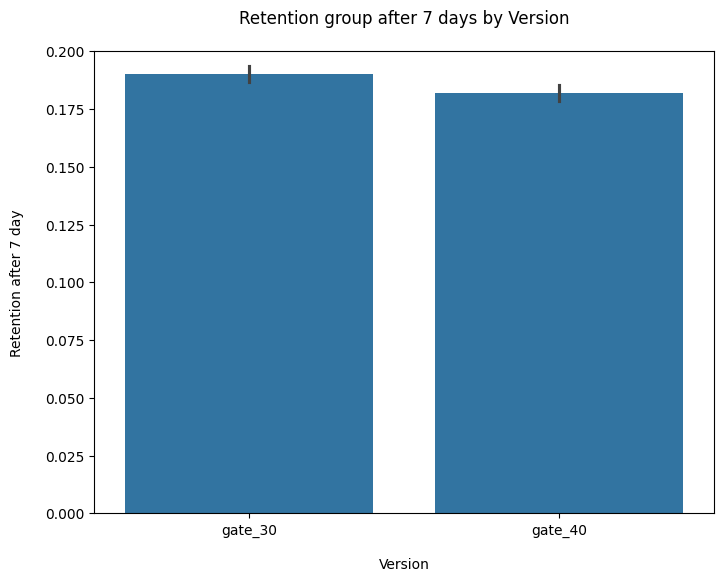

In [40]:
plt.figure(figsize=(8,6))
sns.barplot(x = df['version'], y = df['retention_7'] )
plt.title("Retention group after 7 days by Version", pad = 20)

plt.ylim(0, 0.2)
plt.xlabel('Version', labelpad = 15)
plt.ylabel('Retention after 7 day', labelpad = 15);

З графіку видно, що утримання версії контрольної групи gate_30 спрацювало краще, ніж утримання тестової групи gate_40

**Тестування гіпотези**

In [41]:
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

In [42]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [43]:
control_res = df[df['version'] == 'gate_30']['retention_7']
treatment_res = df[df['version'] == 'gate_40']['retention_7']

In [44]:
n_con = control_res.count()
n_treat = treatment_res.count()
print("The count of control sample:", n_con)
print("The count of treatment sample:",n_treat)
success = [control_res.sum(), treatment_res.sum()]
nobs = [n_con, n_treat]


The count of control sample: 44700
The count of treatment sample: 45489


In [45]:
z_stat, pval = proportions_ztest(success, nobs)
(lower_con, lower_treat),(upper_con,upper_treat) = proportion_confint(success, nobs, alpha = 0.05)
print(f"z statistic: {z_stat:.2f}")
print(f"p-value: {pval:.3f}")
print(f"Confidence interval for control group: [{lower_con:.3f}, {upper_con:.3f}]")
print(f"Confidence interval for treatment group: [{lower_treat:.3f},{upper_treat:.3f}]")

z statistic: 3.16
p-value: 0.002
Confidence interval for control group: [0.187, 0.194]
Confidence interval for treatment group: [0.178,0.186]


**Висновок**

1)Чи є статистична значущою різниця між поведінкою користувачів у різних версіях гри?

  p_value < 0.05, відхиляємо гіпотезу H0

2)Чи перетинаються довірчі інтервали утримання користувачів з різних версій гри? Про що це каже?

  Ні, довірчі інтервали не перетинаються, бачимо, що довірчий інтервал контрольної групи розташований вище [18.7%, 19.4%], ніж довірчий інтервал тестової групи [17.8%, 18.6%]. Це означає, що тестова група (gate_40) не впливає на утримання гравців.

4. Виконайте тест Хі-квадрат на рівні значущості 5% аби визначити, чи є залежність між версією гри та утриманням гравця на 7ий день після реєстрації.

    - Напишіть, як для цього тесту будуть сформульовані гіпотези.
    - Проведіть обчислення, виведіть p-значення і напишіть висновок за результатами тесту.


H0: утримання гравців однакове для усіх груп

Ha: є різниця хоча би між однією парою груп

In [46]:
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [47]:
crosstab = pd.crosstab(df['version'], df['retention_7'])

In [48]:
crosstab

retention_7,False,True
version,,
gate_30,36198,8502
gate_40,37210,8279


In [49]:
chi2, p_value, dof, expected = stats.chi2_contingency(crosstab)

print(f"χ² = {chi2:.3f}")
print(f"p-value = {p_value:.5f}")
print(f"Ступені свободи = {dof}")
print("Очікувані частоти:\n", expected)

χ² = 9.959
p-value = 0.00160
Ступені свободи = 1
Очікувані частоти:
 [[36382.90257127  8317.09742873]
 [37025.09742873  8463.90257127]]


**Висновок:**
p-value < 0.05 -> відхиляємо H0.

Є статистично значуща різниця у конверсії між групами gate_30 і gate_40

**Перевіряємо за допомогою Z-test**

In [61]:
success = crosstab.iloc[:,1]
success

,True
version,
gate_30,8502
gate_40,8279


In [63]:
nobs = crosstab.sum(1)
nobs

,0
version,
gate_30,44700
gate_40,45489


In [64]:
success/nobs

,0
version,
gate_30,0.190201
gate_40,0.182000


H0: в групі gate_30 і gate_40 однакове утримання через 7 днів.

Ha: в групі gate_30 краще утримання, ніж у групі gate_40 через 7 днів.

p1 > p2 (gate_30 > gate_40)

In [70]:
z_stat, pval =  proportions_ztest(success, nobs, alternative='larger')
print(f'z statistic: {z_stat:.2f}')
print(f'p-value: {pval:.5f}')

z statistic: 3.16
p-value: 0.00078


p-value < 0.05 -> відхиляємо H0.

Можно стверджувати, що є статистично значуща різниця між варіантом gate_30 і gate_40.

Утримання групи gate_30 діє ліпше, за утримання групи gate_40.